In [13]:

""" 该notebook主要分为用户分群(分别结合CDA2级教材第9章9.4.3层次聚类应用及9.5聚类算法相关内容)
导入必备库(结合CDA2级教程相关框架及思路)"""
import pandas as pd
from sklearn import preprocessing
from sklearn.decomposition import PCA

model_data=pd.read_csv(r"C:\Users\范彬\OneDrive\桌面\train.csv",encoding='gbk')
model_data.head()

""" 直接运行出现数据类型不匹配问题报错,故经查询资料进行更改"""
print(model_data.dtypes)
model_data2=model_data.select_dtypes(include=["number"])#只选择数值类
"""结合CDA2级9.4.3节P256思路,在主成分分析前使用sklearn库的进行变量中心标准化"""
model_data=preprocessing.scale(model_data2)
"""结合CDA2级7.3.4节P153~P157思路,进行主成分分析"""
pca=PCA(n_components=5)
newData=pca.fit(model_data)
print(pca.explained_variance_)#显示主成分方差
print(pca.explained_variance_ratio_)#显示主成分方差比
""" 由生成结果显示:前3个主成分方差占比大,占比近63%，第一个主成分占比最大,近2.9，前5个主成分总共解释了近83.3%的信息，但系统提醒有较大的极大值影响相关结果."""



Unnamed: 0                 int64
trans_date_trans_time     object
cc_num                     int64
merchant                  object
category                  object
amt                      float64
first                     object
last                      object
gender                    object
street                    object
city                      object
state                     object
zip                        int64
lat                      float64
long                     float64
city_pop                   int64
job                       object
dob                       object
trans_num                 object
unix_time                  int64
merch_lat                float64
merch_long               float64
is_fraud                   int64
dtype: object


D:\python 3.14\Lib\site-packages\sklearn\preprocessing\_data.py:265: UserWarning: Numerical issues were encountered when centering the data and might not be solved. Dataset may contain too large values. You may need to prescale your features.
  warnings.warn(


[2.89601999 2.04807668 1.99896674 1.21948111 1.00640373]
[0.26327434 0.18618865 0.18172411 0.11086183 0.09149118]


' 由生成结果显示:前3个主成分方差占比大,占比近63%，第一个主成分占比最大,近2.9，前5个主成分总共解释了近83.3%的信息，但系统提醒有较大的极大值影响相关结果.'

In [15]:
""" 结合CDA2级9.4.3节P256~P257思路及框架,用fa_kit框架进行主成分分析和因子分析
# 导入库"""
from fa_kit import FactorAnalysis
from  fa_kit import plotting as fa_plotting
fa=FactorAnalysis.load_data_samples(
    model_data,preproc_demean=True,preproc_scale=True
)
fa.extract_components()
"""设定提取主成分的方式,这里使用CDA2级教程推荐方法"top_n"法"""
fa.find_comps_to_retain(method="top_n",num_keep=2)
""" 补充CDA2级教程相关知识点:因子分析法的优势是通过旋转和拉伸让系数极端化,便于理解各变量重要性
# 通过最大方差法进行因子旋转"""
fa.rotate_components(method="varimax")
""" 查看各因子在在各变量下的权重"""
print(pd.DataFrame(fa.comps["rot"]))
"""结合CDA2级教程9.4.3层次聚类应用示例思路及框架,可得出相关结论如下:
# 根据前面的主成分分析结果,设置了2个因子,在进行最大方差的因子旋转后称为因子0和因子1
# 显然,原始变量3，4，5，8，9重要性大,具体可分为2种情况:1.因子0权重大，因子1权重小 2.因子1权重大，因子0权重小 具体如下:
# 1.因子0权重大，因子1权重小类型:原始变量3,5,9
# 2.因子1权重大，因子0权重小类型:原始变量4,8"""


           0         1
0  -0.003649  0.024609
1  -0.038401 -0.071451
2  -0.000472 -0.003563
3  -0.561675 -0.061449
4  -0.004647  0.688508
5   0.583547 -0.034042
6  -0.045855 -0.199150
7  -0.003627  0.024630
8  -0.004773  0.688383
9   0.583389 -0.034048
10  0.001587  0.000947


'结合CDA2级教程9.4.3层次聚类应用示例思路及框架,可得出相关结论如下:\n# 根据前面的主成分分析结果,设置了2个因子,在进行最大方差的因子旋转后称为因子0和因子1\n# 显然,原始变量3，4，5，8，9重要性大,具体可分为2种情况:1.因子0权重大，因子1权重小 2.因子1权重大，因子0权重小 具体如下:\n# 1.因子0权重大，因子1权重小类型:原始变量3,5,9\n# 2.因子1权重大，因子0权重小类型:原始变量4,8'

In [16]:
"""根据CDA2级教程P257指出并加以借鉴修改,对于因子0,主要反映除第二个变量以外的其他变量的信息,所以可以将因子0称为欺诈总量因子,同理根据因子系数的解释,将其命名为Fraud_Avg
# 结合CDA2级教程9.4.3层次聚类应用示例思路及框架,接下来通过这两个因子来展示原始数据的维度,并获得因子得分
# 输出因子得分,为方便拼接,转化 成数据框"""
fa_scores=fa.get_component_scores(model_data)
fa_scores=pd.DataFrame(fa_scores,columns=["Fraud_Gross","Fraud_Avg"])
fa_scores

,Fraud_Gross,Fraud_Avg
0,1.193841,-0.678521
1,-3.403971,2.850157
2,-2.553094,1.132516
3,-2.077306,2.264818
4,1.495292,-0.003503
...,...,...
1296670,-2.588154,-0.145471
1296671,1.622720,0.316541
1296672,-2.095889,-1.271118
1296673,-1.256405,1.434295


   Fraud_Gross  Fraud_Avg
0     0.597393   0.118302
1     0.583858  -0.945475
2    -3.150849  -1.151769
3     0.984677  -2.085166
4     1.652654  -0.113639


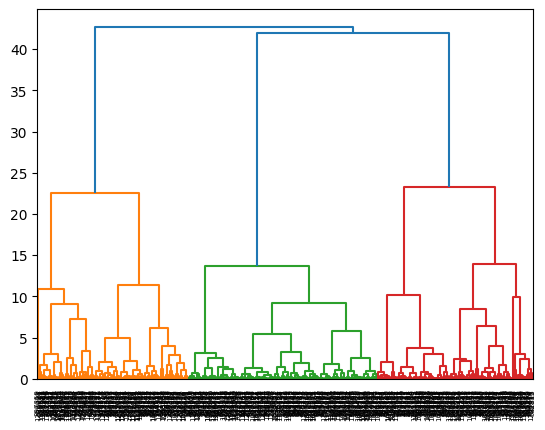

In [17]:
""" 结合CDA2级教程9.4.3层次聚类应用示例思路及框架P259，继续使用教程方法中scipy库进行层次聚类"""
import scipy.cluster.hierarchy as sch
import numpy as np

"""生成点与点的距离矩阵,这里使用欧式距离
disMat=sch.distance.pdist(sampled_df[["Fraud_Gross","Fraud_Avg"]],"euclidean")#教程上使用的citi10_fa,这里直接使用fa_scores
# # 进行层次聚类
# F=sch.linkage(disMat,method="ward")
# # 将层次聚类结果用树状图展示出来"""


"""由于样本集体量较大(超过1000000行),故经过查询资料使用sample抽样法(与02_eda可视化操作相同)
# sampled_df=model_data.sample(n=595,random_state=42)#此处已报错,出现AttributeError,model_data属于numpy数据类型,sample方法仅适用pandas数据类型,查询资料进行优化
# sampled_df=np.random.choice(model_data,size=595,replace=False)#此处再次报错,出现a must be 1-dimensional报错,查询资料进行优化
#再次出现报错,fa_score使用计算体量过大,占用6.12TB,故接下来经过查询资料,先提取出索引,再重新进行抽样
# 生成model_data的索引"""
indices=np.arange(len(model_data))
"""对索引进行随机抽样"""
sampled_indices=np.random.choice(indices, size=595, replace=False)
"""根据抽样索引提取"""
sampled_df=model_data[sampled_indices]

fa_scores2=fa.get_component_scores(sampled_df)
fa_scores2=pd.DataFrame(fa_scores2,columns=["Fraud_Gross","Fraud_Avg"])
print(fa_scores2.head())
""" 再次进行尝试,并将fa_score优化成抽样后的fa_score2"""
disMat=sch.distance.pdist(fa_scores2[["Fraud_Gross","Fraud_Avg"]],"euclidean")
"""进行层次聚类"""
F=sch.linkage(disMat,method="ward")
"""将层次聚类结果用树状图表示出来"""
P=sch.dendrogram(F,labels=sampled_indices)


In [18]:
"""结合CDA2级教程9.5聚类算法思路及框架,先补充相关知识点如下:
# K_maens聚类算法主要分为四个步骤:
# (1)设定k值,确定聚类数,软件随机分配聚类中心所需的种子
# (2)计算每个记录到类中心的距离
# (3)把k值中心作为新的中心,重新计算距离
# (4)迭代至达到标准为止
# K_means算法主要用于用户细分,用户分群部分"""

""" 根据CDA2级教程P260~P269,K-mean聚类算法实操步骤分为项目目的，数据解读，数据预处理，建立聚类模型
# 首先进行数据解读,但由于数据体量极大(TB级),且同为聚类方法,故沿用sample_df作为抽样处理后的数据
# 一.项目目的:在企业内部及相关流程现实场景检索并稽查出欺诈人群及舞弊行为
# 二.数据解读:
直接引用sample_df"""
# indices=["is_fraud","amt","lat","long","city_pop","unix_time","zip"]
# data=sampled_df[indices]
# data
# 报错,出现了indexerror,先查询sample_df 的列名
# print(sampled_indices.columns)
# 报错,发现sampled_index为numpy数据,无columns属性
# print(sampled_indices)
# 检查原先代码,发现model_data已被标准化,找出先前报错原因
model_dataF=pd.read_csv(r"C:\Users\范彬\OneDrive\桌面\train.csv",encoding='gbk')
sampled_dataF=model_dataF.sample(n=595,random_state=42)
# print(sampled_dataF.head())#此处为了简洁,故不进行可视化显示
# 用inidices进行筛选并使用规范dataframe格式
indices=["amt","lat","long","city_pop","unix_time","zip"]
sampled_dataF=pd.DataFrame(sampled_dataF,columns=indices)
sampled_dataF.head()

""" 三.数据预处理
# 结合CDA2级教程思路及框架,补充P262相关知识点:
# 商业聚类算法对变量的基本要求是尽可能反映不同方面的信息,使用聚类算法通常要求样本内无缺失值
# 由于本项目数据集为kaggle冷门公开去敏数据集，查询地址URl:https://www.kaggle.com/datasets/kaushalnandania/credit-card-fraud-detection
# 其本身已进行过数据清洗和数据预处理,故本样本(数据集)并无缺失值的情况
# 结合CDA2级9.5.2的教程思路及框架,接下来查看变量的相关系数矩阵,以判断做变量降维的必要性(非必须)"""
corr_matrix=sampled_dataF.corr(method="pearson")#使用皮尔逊系数 即corr_matrix=corr_matrix.abs()
print(corr_matrix)

"""结合相关资料及皮尔逊系数相关系数矩阵的查询,可以得出以下结论:
long(经度)与zip(邮政编码)的相关系数为-0.903880,说明两者高度线性负相关
lat(纬度)与city_pop(城市人口)的相关系数为-0.159577,lat与zip为-0.1269393,说明维度与城市人口,邮政编码呈现中等程度负相关
多数变量间的相关系数绝对值较小(如amt与其他变量的多在0.03以内),说明这些变量的线性相关性较弱
结合教程结论,相关系数最高的约为0.9,处于必须要做的范围,并且为了解释聚类方便,选择降维处理"""


                amt       lat      long  city_pop  unix_time       zip
amt        1.000000  0.027090  0.002395 -0.011177   0.090646  0.002481
lat        0.027090  1.000000 -0.004439 -0.159577  -0.108113 -0.126393
long       0.002395 -0.004439  1.000000  0.007080   0.081181 -0.903880
city_pop  -0.011177 -0.159577  0.007080  1.000000  -0.019423  0.030357
unix_time  0.090646 -0.108113  0.081181 -0.019423   1.000000 -0.077696
zip        0.002481 -0.126393 -0.903880  0.030357  -0.077696  1.000000


'结合相关资料及皮尔逊系数相关系数矩阵的查询,可以得出以下结论:\nlong(经度)与zip(邮政编码)的相关系数为-0.903880,说明两者高度线性负相关\nlat(纬度)与city_pop(城市人口)的相关系数为-0.159577,lat与zip为-0.1269393,说明维度与城市人口,邮政编码呈现中等程度负相关\n多数变量间的相关系数绝对值较小(如amt与其他变量的多在0.03以内),说明这些变量的线性相关性较弱\n结合教程结论,相关系数最高的约为0.9,处于必须要做的范围,并且为了解释聚类方便,选择降维处理'

In [19]:
"""接下来根据CDA2级中的思路及框架,使用sklearn框架做主成分分析,与先前的标准化操作相同,本次对抽样后样本sampled_dataF进行操作"""
"""from sklearn import preprocessing#先前已经引入相关库,此处注释化，为了显示区别,使用head方法分别显示中心标准化前后变化"""
print(sampled_dataF.head())#原数据集前5行
processed_data=preprocessing.scale(sampled_dataF)
"""print(processed_data.head())#中心标准化的数据集前5行"""
print(processed_data)#中心标准化的数据集前5行
"""proceesed_data属于numpy格式，出现引用的小报错,由于样本体量过大,系统就显示头尾的3行"""


            amt      lat      long  city_pop   unix_time    zip
1045211  194.51  40.6153  -79.4545       972  1362841766  15686
547406    52.32  42.8250 -124.4409       217  1345650541  97476
110142     6.53  39.9636  -79.7853       184  1330824856  15449
1285953    7.33  42.9580  -77.3083     10717  1371413078  14425
271705    64.29  41.6423 -104.1974       635  1336974888  82221
[[ 1.25050929  0.4332888   0.81283811 -0.26132803  1.01109622 -1.27635592]
 [-0.16327425  0.86986882 -2.32346031 -0.26378432 -0.31942025  1.72368937]
 [-0.61856047  0.3045296   0.78977587 -0.26389168 -1.46685552 -1.28504905]
 ...
 [ 0.50250355  0.83163819  1.11038155 -0.2639535  -1.53369191 -1.3623335 ]
 [ 1.07024418  1.19151985 -2.2304305  -0.26150696  0.85221438  1.72005807]
 [ 0.33407052  1.6903358  -0.36918576 -0.24982411 -0.65414853  0.22249297]]


D:\python 3.14\Lib\site-packages\sklearn\preprocessing\_data.py:265: UserWarning: Numerical issues were encountered when centering the data and might not be solved. Dataset may contain too large values. You may need to prescale your features.
  warnings.warn(


'proceesed_data属于numpy格式，出现引用的小报错,由于样本体量过大,系统就显示头尾的3行'

In [12]:
# 接下来根据CDA2级中的思路及框架,使用方差比来计算并评估并保留多少个主成分合适
from sklearn.decomposition import PCA#引入必备的库
"""此处引用CDA2级教程第9章9.5.2 K-means聚类算法应用:用户分群P263相关注释:
说明1:第一次的n_components 参数应该大一点
说明2:观察explained_variance_ratio_累计大于0.85,explained_variance_需要保留的最后一个主成分大于0.8
"""
pca=PCA(n_components=3)
data=pca.fit(processed_data)
print(pca.explained_variance_)
print(pca.explained_variance_ratio_)
# 结果显示,三个主成分之和大约为0.698,大约能解释近70%的数据,但由于小于80%,故将主成分调整至4
print(f"三个主成分之和为{sum(pca.explained_variance_ratio_)}，大约为70%,小于CDA2级教程要求的80%,故将n_components调整至4")

pca1=PCA(n_components=4)
data1=pca1.fit(processed_data)
print(pca1.explained_variance_)
print(pca1.explained_variance_ratio_)
print(f"三个主成分之和为{sum(pca1.explained_variance_ratio_)}，大约为85%,满足CDA2级教程要求的80%,故n_components保留4最合适")
""" 结果显示,四个主成分之和大约为0.854,大约能解释近85%的数据,根据CDA2级9.5.2的思路及框架,得出如下结论:
# 四个主成分能够解释抽样后数据(processed_data)80%以上的变异,所以选用4个主成分适合.接下来查看各主成分在原始变量的权重.如系数极端而且不易于业务解释,需进行因子分析
# 此处数据预处理和主成分,因子分析与先前的聚类方法(fa-kit方法)属于2种,此处使用k-means聚类算法,两种方法流程上有重复处，但均严格按照CDA2级教程思路及框架"""



[1.92794881 1.1916385  1.08734655]
[0.32078476 0.19827262 0.18091985]
三个主成分之和为0.6999772299820981，大约为70%,小于CDA2级教程要求的80%,故将n_components调整至4
[1.92794881 1.1916385  1.08734655 0.93746314]
[0.32078476 0.19827262 0.18091985 0.15598126]
三个主成分之和为0.8559584926398998，大约为85%,满足CDA2级教程要求的80%,故n_components保留4最合适


' 结果显示,四个主成分之和大约为0.854,大约能解释近85%的数据,根据CDA2级9.5.2的思路及框架,得出如下结论:\n# 四个主成分能够解释抽样后数据(processed_data)80%以上的变异,所以选用4个主成分适合.接下来查看各主成分在原始变量的权重.如系数极端而且不易于业务解释,需进行因子分析\n# 此处数据预处理和主成分,因子分析与先前的聚类方法(fa-kit方法)属于2种,此处使用k-means聚类算法,两种方法流程上有重复处，但均严格按照CDA2级教程思路及框架'

In [21]:
"""接下来根据CDA2级教程9.5.2聚类算法应用相关内容，使用k-means算法进行第二次聚类尝试中,
在计算出方差比并确定合适的主成分(n_components)后进行因子分析"""
pd.DataFrame(pca1.components_).T

,0,1,2,3
0,-0.013862,-0.056937,0.702754,0.659300
1,-0.086068,0.714983,0.086085,0.223741
2,-0.696171,-0.079005,-0.079086,0.026360
3,0.035119,-0.564707,-0.372446,0.544411
4,-0.112201,-0.399589,0.591825,-0.465786
5,0.702797,-0.027398,0.059159,-0.035051
